# Week 1 - UR Fall Dataset Preparation

In this notebook we load the UR Fall extracted features, understand the data, check its quality, do simple EDA, and prepare a binary Fall/ADL target for the Week 1 prototype.

## 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the Dataset

In [2]:
columns = [
    "sequence", "frame", "label",
    "HeightWidthRatio", "MajorMinorRatio",
    "BoundingBoxOccupancy", "MaxStdXZ",
    "HHmaxRatio", "H", "D", "P40"
]

falls_url = "https://fenix.ur.edu.pl/mkepski/ds/data/urfall-cam0-falls.csv"
adls_url = "https://fenix.ur.edu.pl/mkepski/ds/data/urfall-cam0-adls.csv"

falls = pd.read_csv(falls_url, header=None, names=columns)
adls = pd.read_csv(adls_url, header=None, names=columns)

print("Fall data shape:", falls.shape)
print("ADL data shape:", adls.shape)

Fall data shape: (2995, 11)
ADL data shape: (8549, 11)


## 3. Combine Fall and ADL Data

In [3]:
falls["activity"] = "Fall"
adls["activity"] = "ADL"

df = pd.concat([falls, adls], ignore_index=True)

df.head()

,sequence,frame,label,HeightWidthRatio,MajorMinorRatio,BoundingBoxOccupancy,MaxStdXZ,HHmaxRatio,H,D,P40,activity
0,fall-01,1,-1,3.1667,2.9098,0.55367,126.0258,1.0324,1899.5366,1055.9988,0.047310,Fall
1,fall-01,2,-1,3.3067,2.9699,0.47876,125.5657,1.1251,2070.1193,1065.9506,0.048175,Fall
2,fall-01,3,-1,3.1408,3.0506,0.54374,123.1570,1.0161,1869.6442,1055.4955,0.050180,Fall
3,fall-01,4,-1,3.4306,3.1435,0.48859,124.5614,1.1251,2070.1193,1076.1464,0.047877,Fall
4,fall-01,5,-1,3.6324,3.3012,0.49744,123.6089,1.1251,2070.1193,1075.5053,0.052543,Fall


## 4. Inspect the Data

In [4]:
print("Dataset shape:", df.shape)
print()
df.info()

Dataset shape: (11544, 12)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11544 entries, 0 to 11543
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   sequence              11544 non-null  object 
 1   frame                 11544 non-null  int64  
 2   label                 11544 non-null  int64  
 3   HeightWidthRatio      11544 non-null  float64
 4   MajorMinorRatio       11544 non-null  float64
 5   BoundingBoxOccupancy  11544 non-null  float64
 6   MaxStdXZ              11544 non-null  float64
 7   HHmaxRatio            11544 non-null  float64
 8   H                     11544 non-null  float64
 9   D                     11544 non-null  float64
 10  P40                   11544 non-null  float64
 11  activity              11544 non-null  object 
dtypes: float64(8), int64(2), object(2)
memory usage: 1.1+ MB


In [5]:
df.describe()

,frame,label,HeightWidthRatio,MajorMinorRatio,BoundingBoxOccupancy,MaxStdXZ,HHmaxRatio,H,D,P40
count,11544.000000,11544.000000,11544.000000,11544.000000,11544.000000,11544.000000,11544.000000,11544.000000,11544.000000,11544.000000
mean,111.420911,-0.439969,1.806710,2.425578,0.548520,174.647473,0.687286,1264.606577,729.564161,0.263388
std,80.294996,0.810911,0.904943,1.051171,0.091995,62.606482,0.270335,497.416861,268.720160,0.289314
min,1.000000,-1.000000,0.173630,1.004800,0.190950,59.116000,0.147720,271.806000,148.271300,0.000000
25%,47.000000,-1.000000,1.008475,1.663100,0.490617,134.976200,0.446685,821.894825,522.410675,0.095628
50%,93.000000,-1.000000,1.832000,2.366650,0.549680,153.516100,0.759025,1396.608200,775.723000,0.149640
75%,163.000000,0.000000,2.559250,2.908650,0.601305,196.998975,0.941553,1732.458225,956.428975,0.269935
max,400.000000,1.000000,7.360000,12.442200,1.157700,477.440700,1.176800,2165.379600,1393.055800,1.000000


## 5. Check Data Quality

In [6]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicated rows:", df.duplicated().sum())

Missing values:
sequence                0
frame                   0
label                   0
HeightWidthRatio        0
MajorMinorRatio         0
BoundingBoxOccupancy    0
MaxStdXZ                0
HHmaxRatio              0
H                       0
D                       0
P40                     0
activity                0
dtype: int64

Duplicated rows: 0


## 6. Understand the Labels

The original `label` describes the person's posture in each frame:

- `-1` = not lying
- `0` = transition / falling
- `1` = lying

The `activity` column is different. It tells us whether the frame belongs to a **Fall** sequence or an **ADL** (normal activity) sequence.

For Week 1, we keep the original rows and use `activity` only as a simple Fall/ADL class marker.

In [7]:
print("Original posture labels:")
print(df["label"].value_counts().sort_index())

print("\nFall vs ADL:")
print(df["activity"].value_counts())

Original posture labels:
label
-1    7452
 0    1719
 1    2373
Name: count, dtype: int64

Fall vs ADL:
activity
ADL     8549
Fall    2995
Name: count, dtype: int64


In [8]:
pd.crosstab(df["activity"], df["label"])

label,-1,0,1
activity,,,
ADL,6260,819,1470
Fall,1192,900,903


## 7. Exploratory Data Analysis

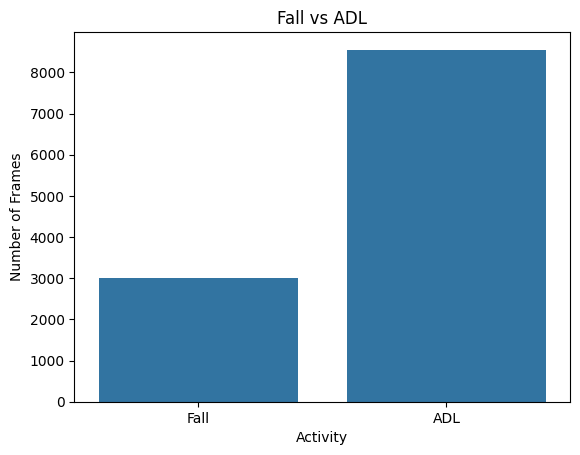

In [9]:
sns.countplot(data=df, x="activity")
plt.title("Fall vs ADL")
plt.xlabel("Activity")
plt.ylabel("Number of Frames")
plt.show()

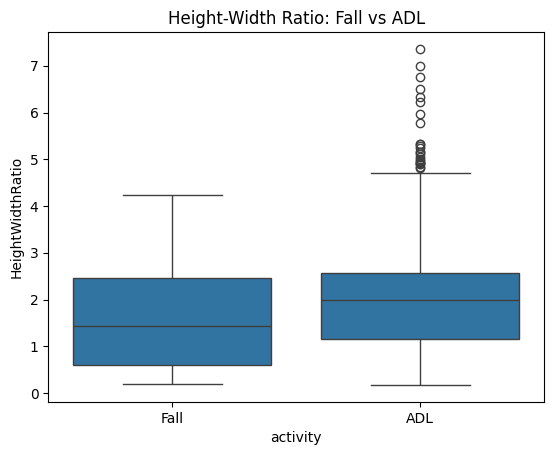

In [10]:
sns.boxplot(data=df, x="activity", y="HeightWidthRatio")
plt.title("Height-Width Ratio: Fall vs ADL")
plt.show()

## 8. Prepare the Week 1 ML Target

`fall_target` is a simple Week 1 marker:

- `1` = frame belongs to a Fall sequence
- `0` = frame belongs to an ADL sequence

It is not the final temporal fall-detection model yet.

In [11]:
df["fall_target"] = df["activity"].map({
    "Fall": 1,
    "ADL": 0
})

features = [
    "HeightWidthRatio",
    "MajorMinorRatio",
    "BoundingBoxOccupancy",
    "MaxStdXZ",
    "HHmaxRatio",
    "H",
    "D",
    "P40"
]

X = df[features]
y = df["fall_target"]

X.head()

,HeightWidthRatio,MajorMinorRatio,BoundingBoxOccupancy,MaxStdXZ,HHmaxRatio,H,D,P40
0,3.1667,2.9098,0.55367,126.0258,1.0324,1899.5366,1055.9988,0.047310
1,3.3067,2.9699,0.47876,125.5657,1.1251,2070.1193,1065.9506,0.048175
2,3.1408,3.0506,0.54374,123.1570,1.0161,1869.6442,1055.4955,0.050180
3,3.4306,3.1435,0.48859,124.5614,1.1251,2070.1193,1076.1464,0.047877
4,3.6324,3.3012,0.49744,123.6089,1.1251,2070.1193,1075.5053,0.052543


In [12]:
print(y.value_counts())

fall_target
0    8549
1    2995
Name: count, dtype: int64


## 9. Save the Prepared Dataset

In [13]:
df.to_csv("urfall_cleaned.csv", index=False)

print("Dataset saved as urfall_cleaned.csv")
print("Final shape:", df.shape)

Dataset saved as urfall_cleaned.csv
Final shape: (11544, 13)


### Week 1 Summary

- Loaded the Fall and ADL feature files.
- Combined them into one DataFrame.
- Inspected the columns, data types, and basic statistics.
- Checked missing values and duplicated rows.
- Understood the difference between the original posture `label` and Fall/ADL `activity`.
- Performed simple visual exploration.
- Created a temporary binary target for the Week 1 classifier prototype.
- Saved the prepared dataset.